<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell Deformation Estimation with VoxelMorph

2D deformable registration for PhC-C2DH-U373 cells using VoxelMorph, compared against Horn & Schunck classical optical flow baseline.

## 1. Imports

In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

## 2. Repo Clone

In [ ]:
!git clone https://github.com/abdullahh-sheikhh/voxelmorph.git
%cd voxelmorph
!git checkout dev
!pip install -e . -q
!pip install -r scripts/cell_tracking/requirements.txt -q
!pip install 'numpy<2.1' -q  # avoid scipy/skimage conflict on Colab

## 3. Dataset Download and Setup

Fetch and unpack the PhC-C2DH-U373 training data (sequences 01 and 02) from the Cell Tracking Challenge into `dataset/train/`.

In [ ]:
from pathlib import Path

!mkdir -p dataset

if not Path('dataset/train/01').exists():
    print('Downloading training data...')
    !wget -q https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip -O dataset/train.zip
    !cd dataset && unzip -q train.zip -d train_raw && mv train_raw/PhC-C2DH-U373/* train/ && rm -rf train_raw train.zip
else:
    print('Training data already exists')

!echo "Train sequences:" && ls dataset/train/01/ | head -3 && echo "... (115 frames total)"

## 4. Dataset Visualize

What we are working with and what we are trying to do.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from skimage import io
from pathlib import Path

#  Load two consecutive frames and their Silver Truth masks ─
frame_i, frame_j = 10, 11
seq_dir = Path('dataset/train/01')
st_dir  = Path('dataset/train/01_ST/SEG')

img_i  = io.imread(str(seq_dir / f't{frame_i:03d}.tif')).astype(np.float32) / 255.0
img_j  = io.imread(str(seq_dir / f't{frame_j:03d}.tif')).astype(np.float32) / 255.0
diff   = np.abs(img_j - img_i)

mask_i = io.imread(str(st_dir / f'man_seg{frame_i:03d}.tif')).astype(np.float32)
mask_j = io.imread(str(st_dir / f'man_seg{frame_j:03d}.tif')).astype(np.float32)

binary_i = mask_i > 0
binary_j = mask_j > 0
n_cells  = int(mask_i.max())

# Per-cell colour map: background = black, each cell = distinct colour
cell_cmap = ListedColormap(['black'] + [cm.tab10(i % 10) for i in range(n_cells)])

# Alignment overlay: red = source cells, green = target cells, yellow = overlap
align_rgb         = np.zeros((*img_i.shape, 3), dtype=np.float32)
align_rgb[..., 0] = binary_i.astype(float)
align_rgb[..., 1] = binary_j.astype(float)

#  Figure: 3 rows × 3 panels ─
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

kw_img = dict(cmap='gray', vmin=0, vmax=1)
kw_src = dict(colors=['#00d4ff'], linewidths=0.9, levels=[0.5])   # cyan  = source
kw_tgt = dict(colors=['#ffcc00'], linewidths=0.9, levels=[0.5])   # yellow = target

#  Row 0: single frame anatomy ─
axes[0, 0].imshow(img_i, **kw_img)
axes[0, 0].set_title(
    f'Frame t={frame_i}  —  raw phase-contrast image\n'
    f'696×520 px  |  8-bit grayscale  |  0.65 μm/pixel  |  15 min/frame', fontsize=9)

axes[0, 1].imshow(img_i, **kw_img)
axes[0, 1].contour(binary_i.astype(float), **kw_src)
axes[0, 1].set_title(
    f'Silver Truth cell regions  ({n_cells} cells)\n'
    f'Cyan contours = ST masks  —  used as training supervision', fontsize=9)

axes[0, 2].imshow(mask_i, cmap=cell_cmap, vmin=0, vmax=n_cells, interpolation='nearest')
axes[0, 2].set_title(
    f'Cell label map  (0 = background, 1–{n_cells} = individual cells)\n'
    f'Integer IDs are stable across frames (tracking IDs)', fontsize=9)

#  Row 1: consecutive pair
axes[1, 0].imshow(img_i, **kw_img)
axes[1, 0].contour(binary_i.astype(float), **kw_src)
axes[1, 0].set_title(f'Source frame  t={frame_i}  (cyan = cell boundaries)', fontsize=9)

axes[1, 1].imshow(img_j, **kw_img)
axes[1, 1].contour(binary_j.astype(float), **kw_tgt)
axes[1, 1].set_title(f'Target frame  t={frame_j}  (+15 min)  (yellow = cell boundaries)', fontsize=9)

im = axes[1, 2].imshow(diff, cmap='inferno', vmin=0, vmax=diff.max())
axes[1, 2].set_title('|Target − Source|  —  where intensity changed\nBright = cells moved / deformed', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

#  Row 2: the registration problem ─
axes[2, 0].imshow(binary_i.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title(
    f'Source mask  (binary)\n'
    f'Cell area = {binary_i.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 1].imshow(binary_j.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 1].set_title(
    f'Target mask  (binary)\n'
    f'Cell area = {binary_j.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 2].imshow(align_rgb)
axes[2, 2].set_title(
    'Goal: warp source mask → target mask\n'
    'Red = source  |  Green = target  |  Yellow = overlap', fontsize=9)

#  Row labels & final formatting ─
row_labels = ['What the\ndata looks like', 'What we\nregister', 'The alignment\nproblem']
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label, xy=(-0.14, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=8, fontweight='bold',
        rotation=90, color='#444444')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(
    'PhC-C2DH-U373  —  Glioblastoma-astrocytoma U373 cells  |  Phase-contrast microscopy  |  Seq 01\n'
    '115 frames  ·  228 consecutive pairs  ·  3–8 cells per frame  ·  Silver Truth masks on all frames',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Trainings

Train five VoxelMorph variants on sequence 01 (full-frame 704×544 pairs). Each subsection runs `train.py` with a different image-similarity loss and displays the resulting training curve.

### 5.1 Masked MSE

Train **Masked MSE** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks (primary alignment signal)
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 0.01` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/masked_mse \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/masked_mse/loss_curve.png', width=800))

### 5.2 NCC

Train **Normalized Cross-Correlation** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ncc \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/ncc/loss_curve.png', width=800))

### 5.3 SSIM

Train **SSIM** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ssim --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ssim \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/ssim/loss_curve.png', width=800))

### 5.4 NCC+SSIM

Train **NCC+SSIM** for 200 epochs on sequence 01.

Loss terms:
- Equal-weight combination of NCC and SSIM intensity losses
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted combined intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ncc+ssim --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ncc_ssim \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/ncc_ssim/loss_curve.png', width=800))

### 5.5 MSE+NCC+SSIM

Train **MSE+NCC+SSIM** for 200 epochs on sequence 01.

Loss terms:
- Equal-weight combination of MSE, NCC, and SSIM intensity losses
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted combined intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss mse+ncc+ssim --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/mse_ncc_ssim \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/mse_ncc_ssim/loss_curve.png', width=800))

## 6. Validations

Evaluate each trained model on held-out sequence 02. Each run also computes the Horn & Schunck, Farneback, and TV-L1 baselines on the same pairs and writes them to its `output/eval_*/metrics.json`.

### 6.1 Masked MSE

Evaluate on held-out sequence 02. Includes Horn & Schunck, Farneback, and TV-L1 baselines.

In [16]:
!python -m scripts.cell_tracking.evaluate \
    --model output/masked_mse/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_masked_mse \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: True

Evaluating 114 pairs...

  Pair 0: Dice=0.8688, MaskedMSE=0.007010
  Pair 1: Dice=0.7990, MaskedMSE=0.008644
  Pair 2: Dice=0.8350, MaskedMSE=0.009388
  Pair 3: Dice=0.7297, MaskedMSE=0.007917
  Pair 4: Dice=0.8530, MaskedMSE=0.006418
  Pair 5: Dice=0.8763, MaskedMSE=0.006229
  Pair 6: Dice=0.8296, MaskedMSE=0.005898
  Pair 7: Dice=0.8666, MaskedMSE=0.005305
  Pair 8: Dice=0.8534, MaskedMSE=0.006044
  Pair 9: Dice=0.8550, MaskedMSE=0.006201
  Pair 10: Dice=0.8012, MaskedMSE=0.005840
  Pair 11: Dice=0.8381, MaskedMSE=0.006054
  Pair 12: Dice=0.8580, MaskedMSE=0.006151
  Pair 13: Dice=0.7349, MaskedMSE=0.007553
  Pair 14: Dice=0.7750, MaskedMSE=0.008166
  Pair 15: Dice=0.8537, MaskedMSE=0.006754
  Pair 16: Dice=0.8830, MaskedMSE=0.006727
  Pair 17: Dice=0.8415, MaskedMSE=0.006060
  Pair 18: Dice=0.8778, MaskedMSE=0.006129
  Pair 19: Dice=0.8744, MaskedMSE=0.006567
  Pair 20: Dice=0.8605, MaskedMSE=0.006514
  Pair 21: Dice=0.6732

pair_0000.png


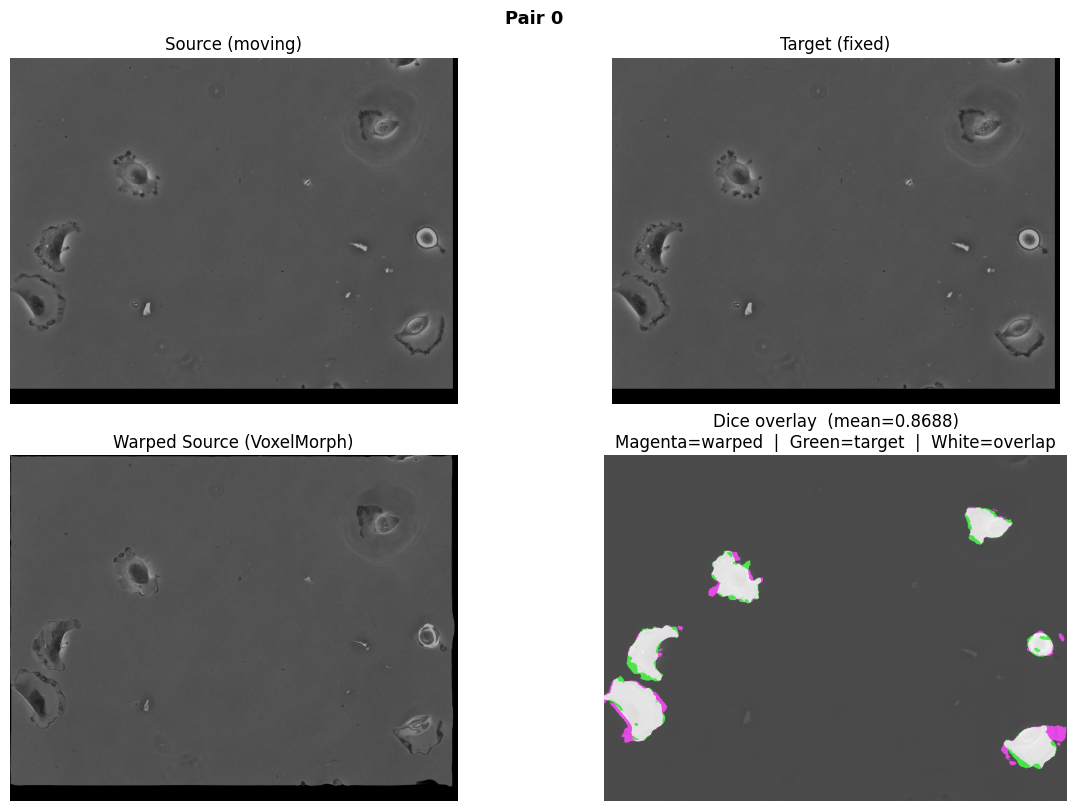

pair_0001.png


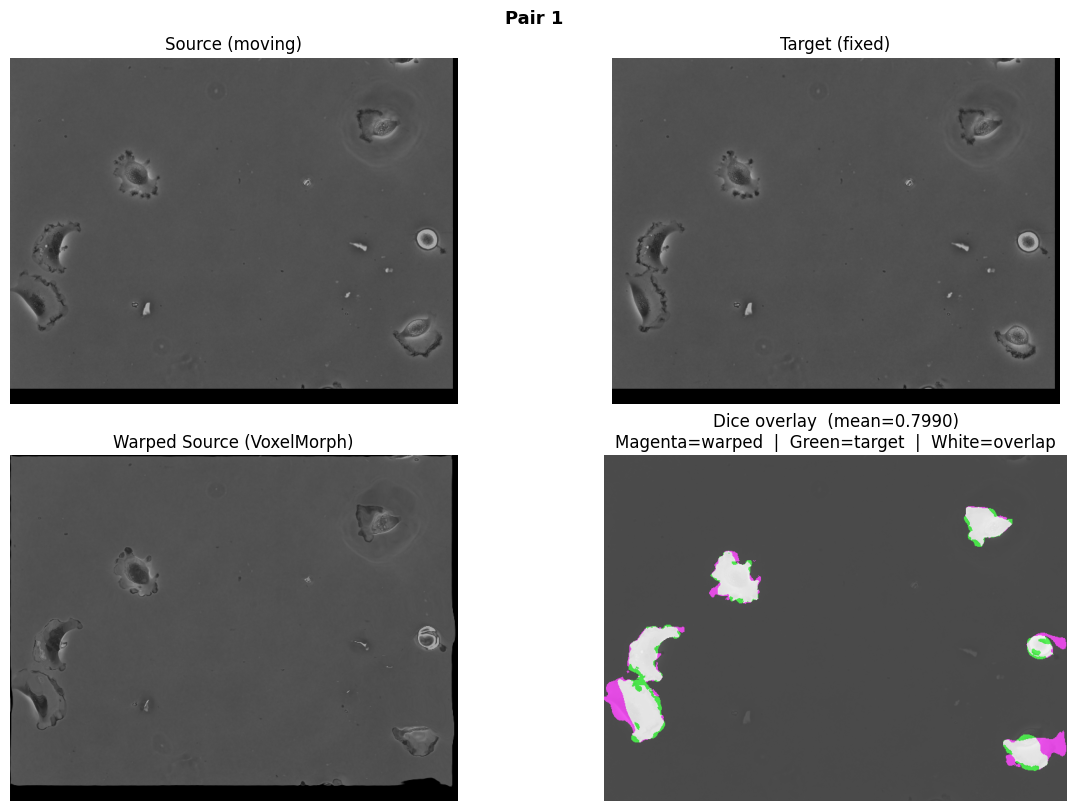

pair_0002.png


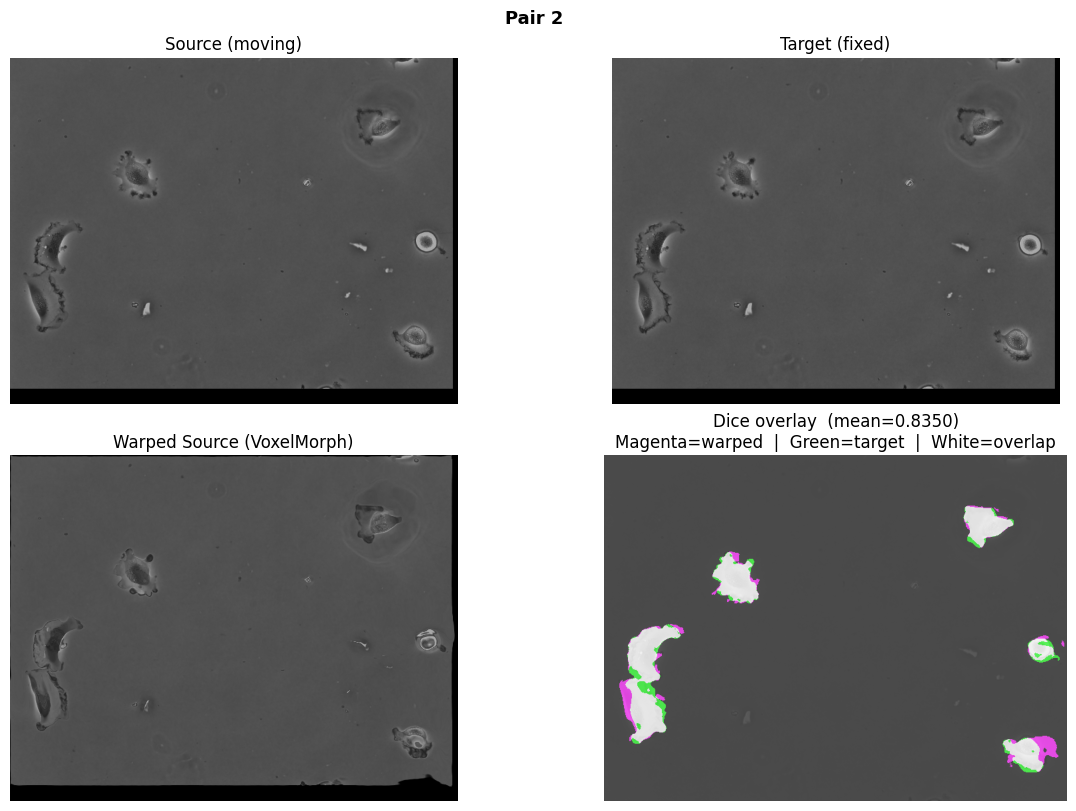

In [17]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_masked_mse').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

### 6.2 NCC

Evaluate on held-out sequence 02. Baseline numbers reused from section 7.

In [18]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ncc/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ncc \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9167, MaskedMSE=0.002750
  Pair 1: Dice=0.8638, MaskedMSE=0.005563
  Pair 2: Dice=0.8899, MaskedMSE=0.005447
  Pair 3: Dice=0.7661, MaskedMSE=0.003949
  Pair 4: Dice=0.8963, MaskedMSE=0.003412
  Pair 5: Dice=0.9098, MaskedMSE=0.003970
  Pair 6: Dice=0.9218, MaskedMSE=0.002850
  Pair 7: Dice=0.9235, MaskedMSE=0.002337
  Pair 8: Dice=0.9016, MaskedMSE=0.003067
  Pair 9: Dice=0.9011, MaskedMSE=0.003398
  Pair 10: Dice=0.9102, MaskedMSE=0.002534
  Pair 11: Dice=0.9135, MaskedMSE=0.003140
  Pair 12: Dice=0.9091, MaskedMSE=0.003217
  Pair 13: Dice=0.7692, MaskedMSE=0.003299
  Pair 14: Dice=0.8928, MaskedMSE=0.004440
  Pair 15: Dice=0.8981, MaskedMSE=0.003346
  Pair 16: Dice=0.9148, MaskedMSE=0.002951
  Pair 17: Dice=0.9036, MaskedMSE=0.002682
  Pair 18: Dice=0.9283, MaskedMSE=0.002547
  Pair 19: Dice=0.9309, MaskedMSE=0.002528
  Pair 20: Dice=0.8996, MaskedMSE=0.002950
  Pair 21: Dice=0.705

### 6.3 SSIM

Evaluate on held-out sequence 02. Baseline numbers reused from section 7.

In [19]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ssim/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ssim \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9098, MaskedMSE=0.002833
  Pair 1: Dice=0.8580, MaskedMSE=0.005363
  Pair 2: Dice=0.8707, MaskedMSE=0.005508
  Pair 3: Dice=0.7594, MaskedMSE=0.005601
  Pair 4: Dice=0.8894, MaskedMSE=0.004185
  Pair 5: Dice=0.8994, MaskedMSE=0.004508
  Pair 6: Dice=0.9126, MaskedMSE=0.004044
  Pair 7: Dice=0.9114, MaskedMSE=0.003005
  Pair 8: Dice=0.8928, MaskedMSE=0.003686
  Pair 9: Dice=0.8942, MaskedMSE=0.004263
  Pair 10: Dice=0.9015, MaskedMSE=0.004217
  Pair 11: Dice=0.9025, MaskedMSE=0.004766
  Pair 12: Dice=0.9003, MaskedMSE=0.004473
  Pair 13: Dice=0.7592, MaskedMSE=0.004120
  Pair 14: Dice=0.8831, MaskedMSE=0.005305
  Pair 15: Dice=0.8909, MaskedMSE=0.004115
  Pair 16: Dice=0.9127, MaskedMSE=0.003791
  Pair 17: Dice=0.8944, MaskedMSE=0.003630
  Pair 18: Dice=0.9190, MaskedMSE=0.002837
  Pair 19: Dice=0.9253, MaskedMSE=0.002851
  Pair 20: Dice=0.8820, MaskedMSE=0.003921
  Pair 21: Dice=0.690

pair_0000.png


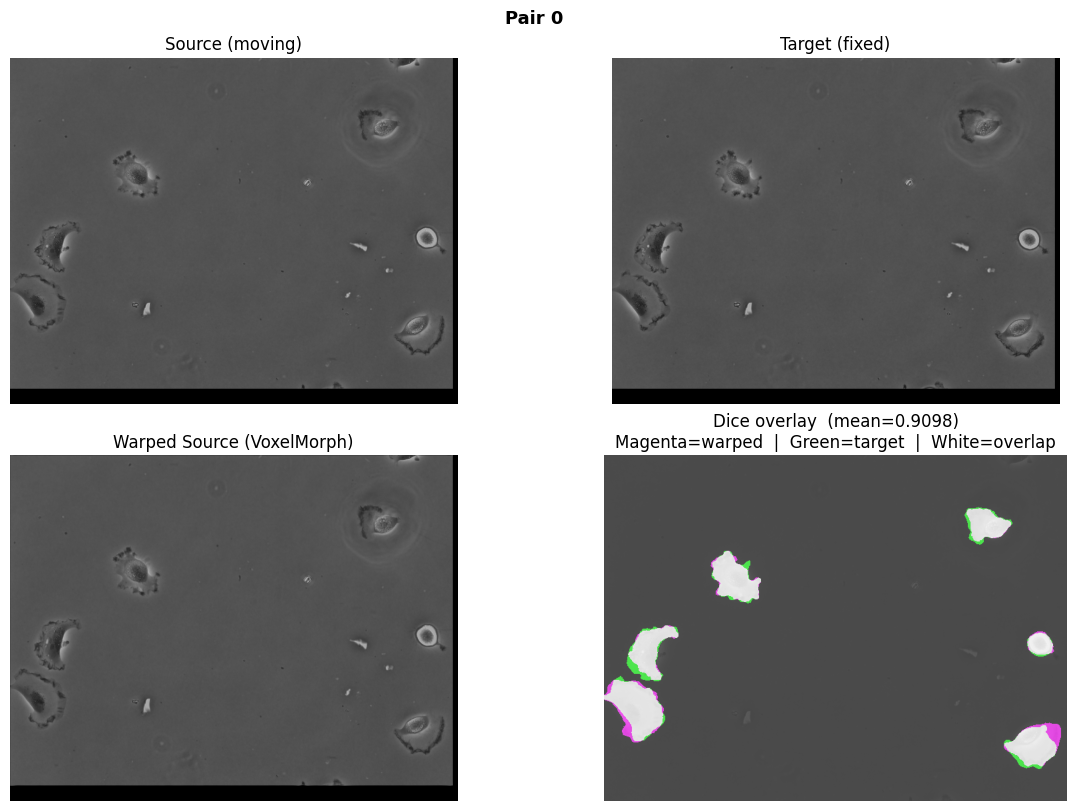

pair_0001.png


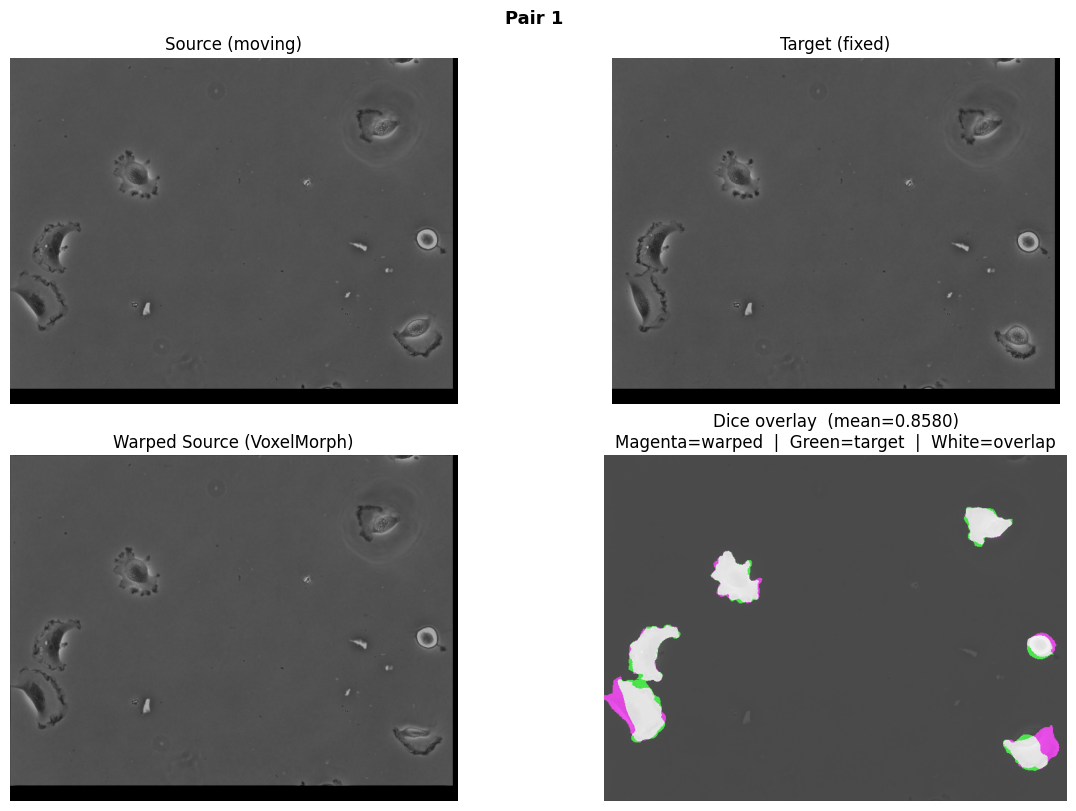

pair_0002.png


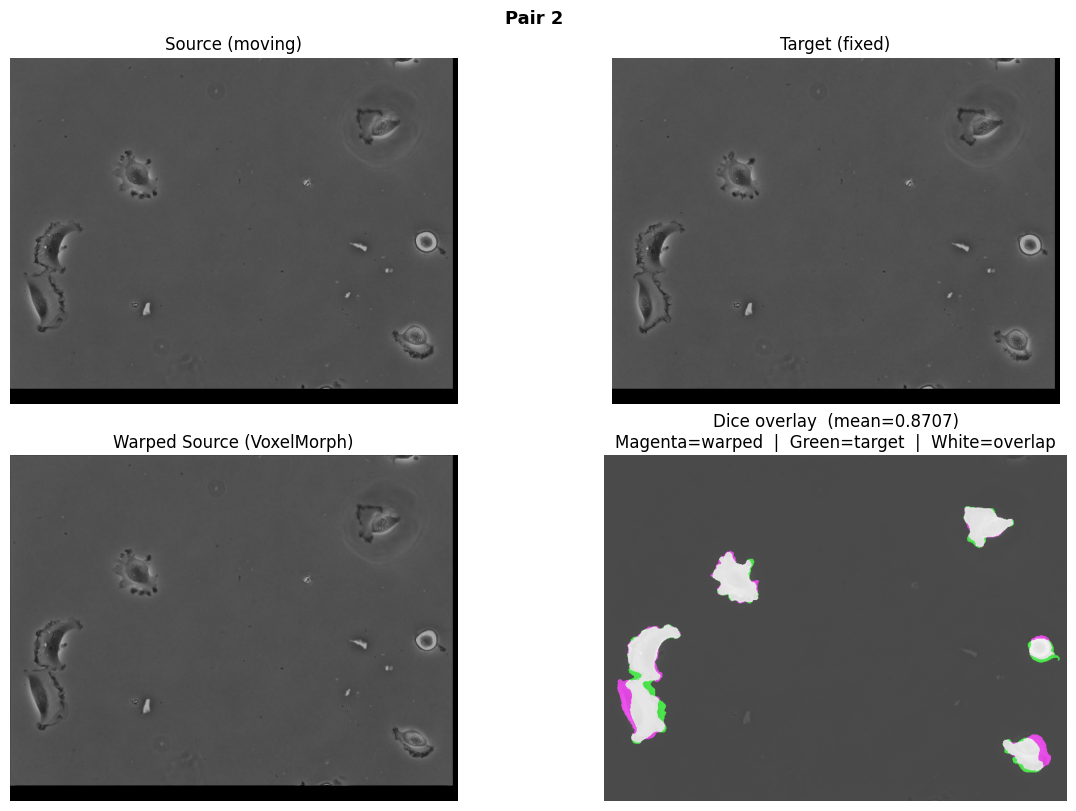

In [20]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_ssim').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

### 6.4 NCC+SSIM

Evaluate on held-out sequence 02. Baseline numbers reused from section 9.

In [21]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ncc_ssim/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ncc_ssim \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9170, MaskedMSE=0.002424
  Pair 1: Dice=0.8719, MaskedMSE=0.005240
  Pair 2: Dice=0.8863, MaskedMSE=0.005371
  Pair 3: Dice=0.7709, MaskedMSE=0.005964
  Pair 4: Dice=0.8992, MaskedMSE=0.004077
  Pair 5: Dice=0.9102, MaskedMSE=0.004367
  Pair 6: Dice=0.9275, MaskedMSE=0.003730
  Pair 7: Dice=0.9201, MaskedMSE=0.002779
  Pair 8: Dice=0.9038, MaskedMSE=0.003427
  Pair 9: Dice=0.9138, MaskedMSE=0.004035
  Pair 10: Dice=0.9214, MaskedMSE=0.003790
  Pair 11: Dice=0.9150, MaskedMSE=0.004475
  Pair 12: Dice=0.9142, MaskedMSE=0.004132
  Pair 13: Dice=0.7628, MaskedMSE=0.003684
  Pair 14: Dice=0.8924, MaskedMSE=0.004885
  Pair 15: Dice=0.9121, MaskedMSE=0.003579
  Pair 16: Dice=0.9177, MaskedMSE=0.003299
  Pair 17: Dice=0.9072, MaskedMSE=0.003218
  Pair 18: Dice=0.9262, MaskedMSE=0.002595
  Pair 19: Dice=0.9273, MaskedMSE=0.002593
  Pair 20: Dice=0.8938, MaskedMSE=0.003739
  Pair 21: Dice=0.708

pair_0000.png


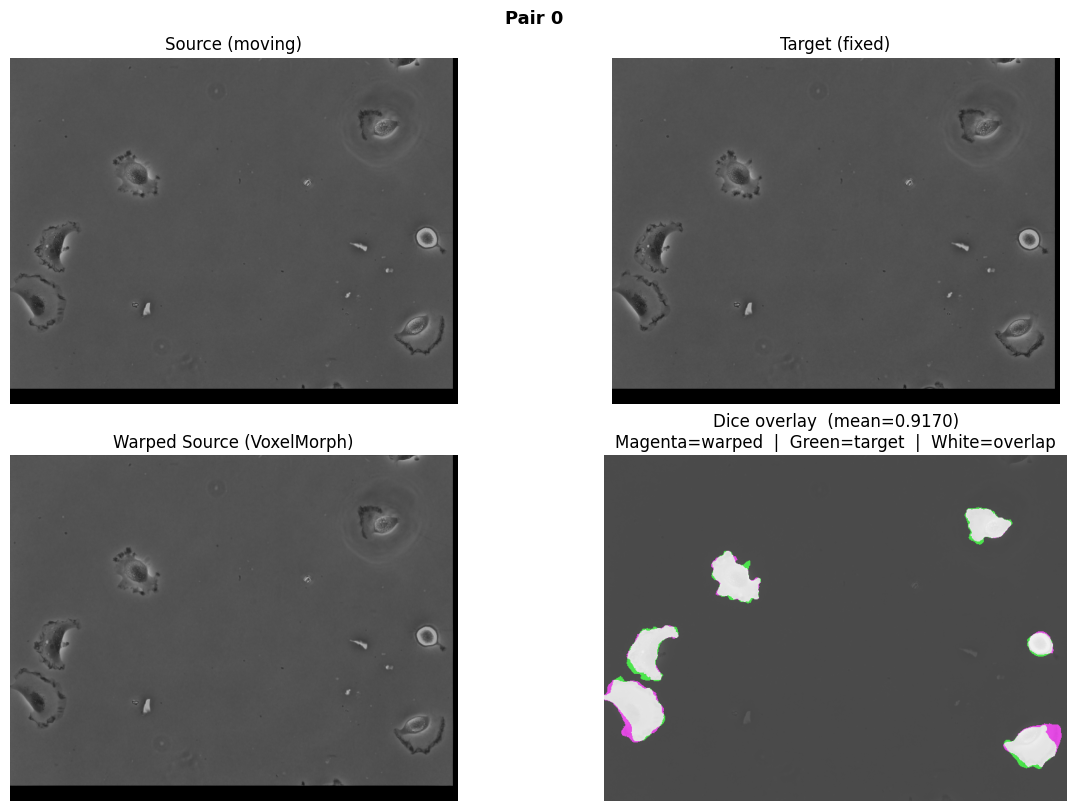

pair_0001.png


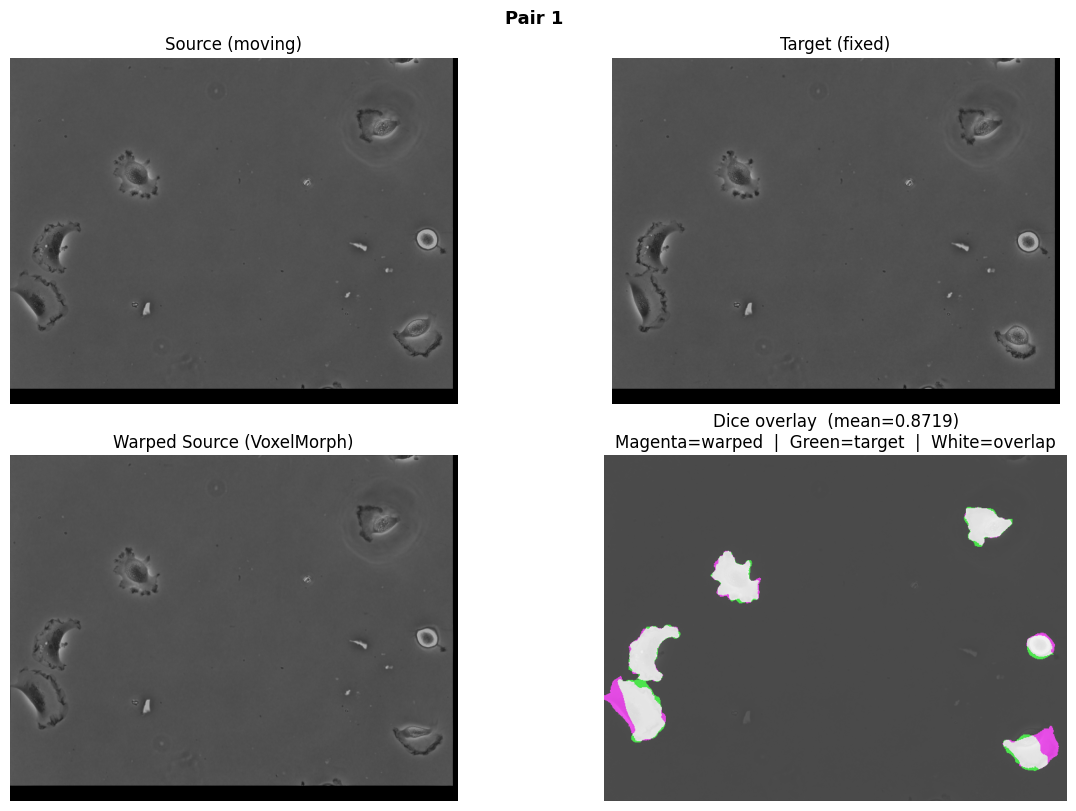

pair_0002.png


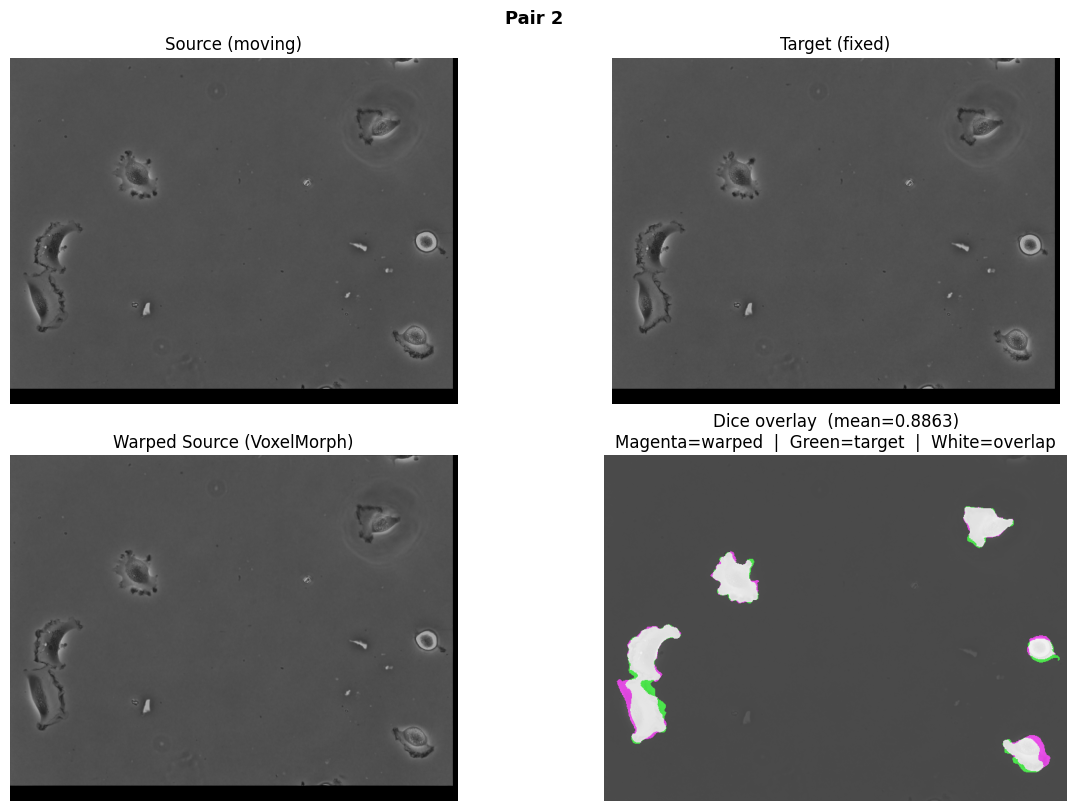

In [22]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_ncc_ssim').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

### 6.5 MSE+NCC+SSIM

Evaluate on held-out sequence 02. Baseline numbers reused from section 9.

In [23]:
!python -m scripts.cell_tracking.evaluate \
    --model output/mse_ncc_ssim/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_mse_ncc_ssim \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9192, MaskedMSE=0.002807
  Pair 1: Dice=0.8632, MaskedMSE=0.005466
  Pair 2: Dice=0.8878, MaskedMSE=0.005584
  Pair 3: Dice=0.7710, MaskedMSE=0.005535
  Pair 4: Dice=0.8957, MaskedMSE=0.004287
  Pair 5: Dice=0.9089, MaskedMSE=0.004514
  Pair 6: Dice=0.9161, MaskedMSE=0.003942
  Pair 7: Dice=0.9223, MaskedMSE=0.002981
  Pair 8: Dice=0.9076, MaskedMSE=0.003841
  Pair 9: Dice=0.9084, MaskedMSE=0.004572
  Pair 10: Dice=0.9067, MaskedMSE=0.004326
  Pair 11: Dice=0.9129, MaskedMSE=0.004847
  Pair 12: Dice=0.9134, MaskedMSE=0.004582
  Pair 13: Dice=0.7668, MaskedMSE=0.004120
  Pair 14: Dice=0.8855, MaskedMSE=0.005224
  Pair 15: Dice=0.8948, MaskedMSE=0.004073
  Pair 16: Dice=0.9160, MaskedMSE=0.003738
  Pair 17: Dice=0.9074, MaskedMSE=0.003729
  Pair 18: Dice=0.9247, MaskedMSE=0.003023
  Pair 19: Dice=0.9266, MaskedMSE=0.003142
  Pair 20: Dice=0.8992, MaskedMSE=0.004047
  Pair 21: Dice=0.700

pair_0000.png


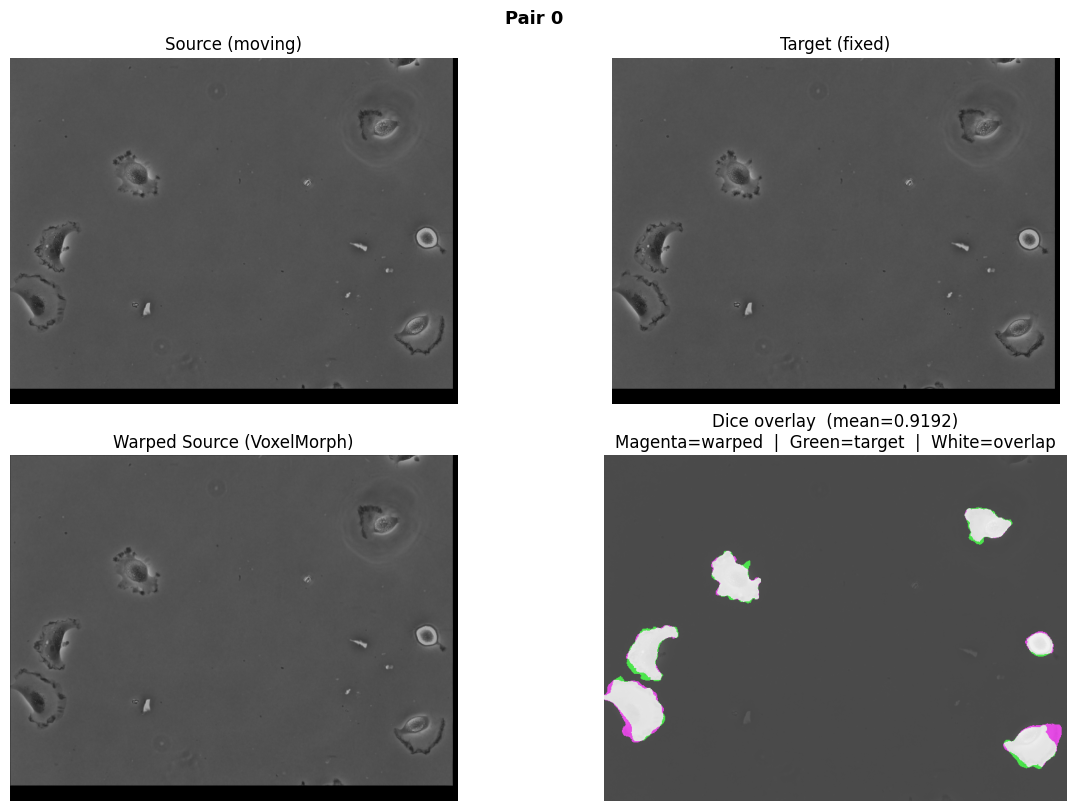

pair_0001.png


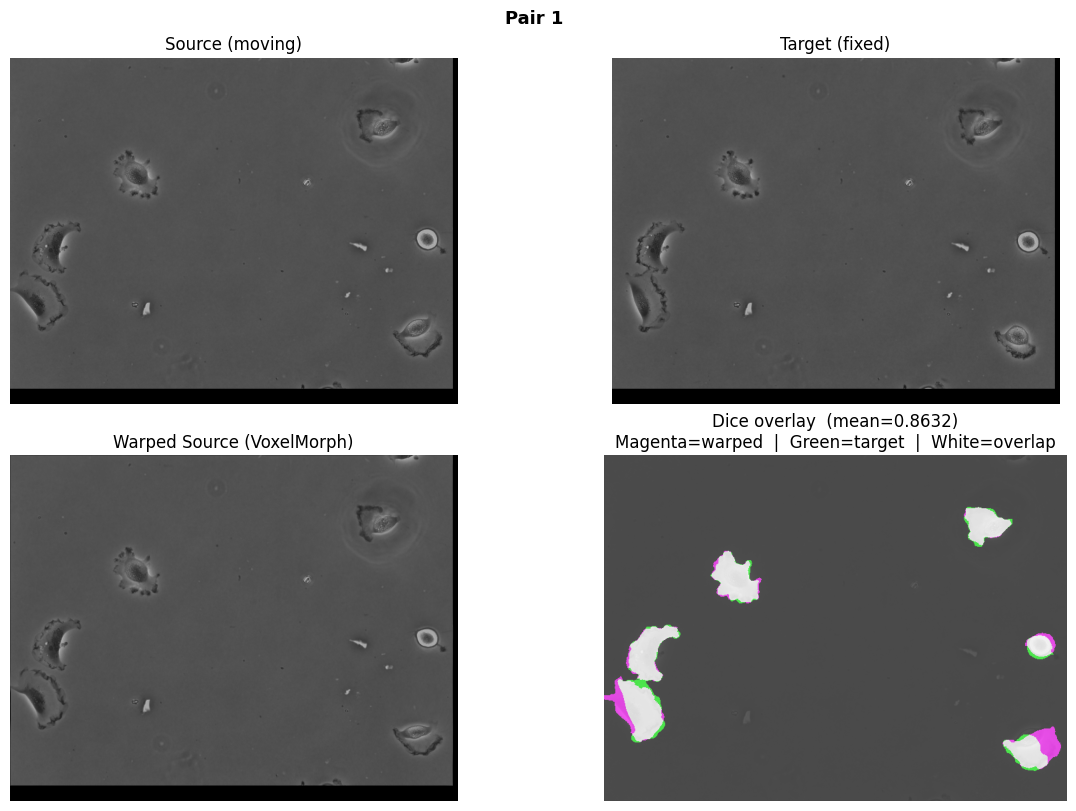

pair_0002.png


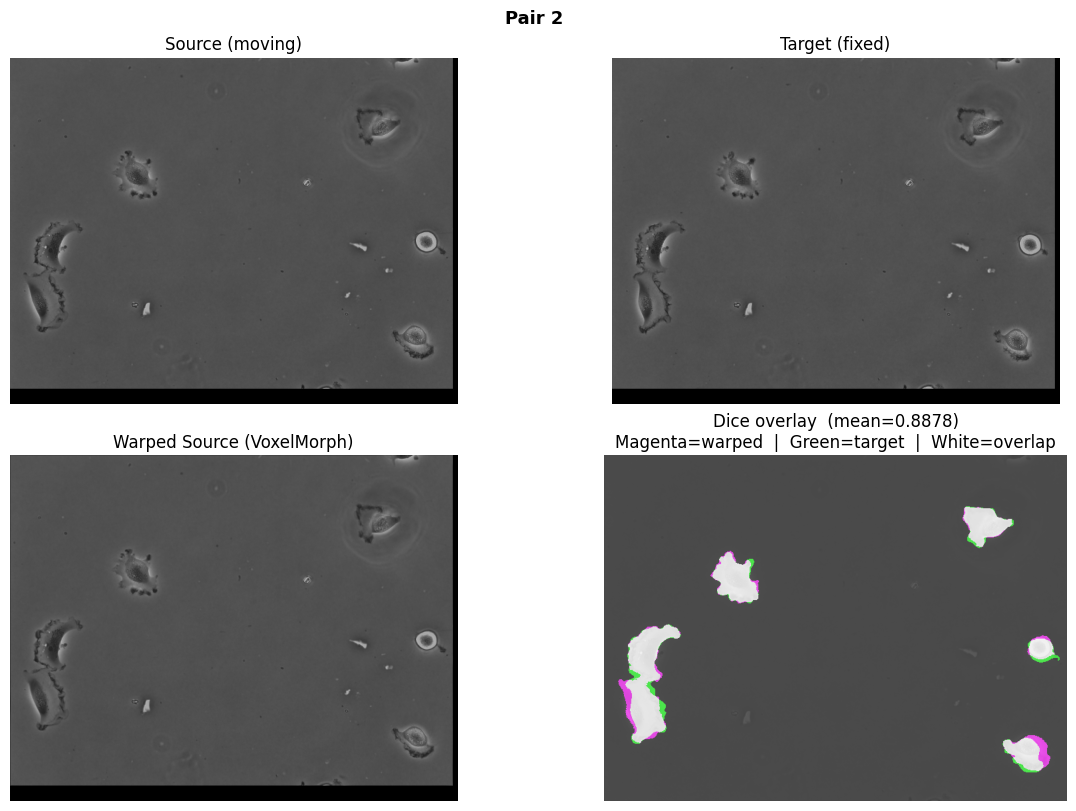

In [24]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_mse_ncc_ssim').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

## 7. New Dataset Creation

Extract individual cells from every consecutive frame pair into 224x224 isolated crops (other cells zeroed out). Saves ~2300 NPZ samples to dataset/segmented_cells/, then visualizes four examples to confirm the segregation worked.

In [ ]:
from scripts.cell_tracking.cell_segmentation import SegmentedCellBuilder

builder = SegmentedCellBuilder(
    data_dir="dataset/train",
    output_dir="dataset/segmented_cells",
    crop_size=224,
)
builder.build(sequences=["01", "02"])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

crop_dir = Path("dataset/segmented_cells")
crop_files = sorted(crop_dir.glob("*.npz"))
print(f"Total segmented cell crops: {len(crop_files)}")

n_examples = 4
indices = np.linspace(0, len(crop_files) - 1, n_examples, dtype=int)

fig, axes = plt.subplots(n_examples, 4, figsize=(14, 3.5 * n_examples))

for row, idx in enumerate(indices):
    data = np.load(str(crop_files[idx]))
    name = crop_files[idx].stem

    axes[row, 0].imshow(data["source"], cmap="gray")
    axes[row, 0].set_title(f"{name}\nsource", fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(data["target"], cmap="gray")
    axes[row, 1].set_title("target", fontsize=10)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(data["source_mask"], cmap="gray")
    axes[row, 2].set_title("source mask", fontsize=10)
    axes[row, 2].axis("off")

    axes[row, 3].imshow(data["target_mask"], cmap="gray")
    axes[row, 3].set_title("target mask", fontsize=10)
    axes[row, 3].axis("off")

plt.suptitle("Per-Cell Segmented Crops — Sample Inspection", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 8. New Dataset Training

Train VoxelMorph with NCC+SSIM loss on the segmented cell crops. Sequence 01 trains, Sequence 02 validates each epoch.

In [ ]:
!python -m scripts.cell_tracking.train_segmented_cells \
    --data-dir dataset/segmented_cells \
    --epochs 200 \
    --output-dir output/segmented_cells_ncc_ssim

from IPython.display import Image, display
display(Image(filename="output/segmented_cells_ncc_ssim/loss_curve.png"))

## 9. New Dataset Validations

Evaluate Horn & Schunck, Farneback, and TV-L1 on every cell crop in the sequence-02 validation split. Writes per-baseline Dice and runtime to `output/segmented_cells_baselines/metrics.json`.

In [ ]:
!python -m scripts.cell_tracking.evaluate_segmented_cells_baselines \
    --data-dir dataset/segmented_cells \
    --val-sequence 02 \
    --output-dir output/segmented_cells_baselines

## 10. Results — Original Dataset

Comparison of classical baselines and VoxelMorph variants on the full-frame 704×544 pairs (held-out sequence 02). All Dice/MSE/runtime numbers are per-pair.

In [25]:
import json
import pandas as pd
from pathlib import Path


def load_metrics(path: str, key: str):
    p = Path(path)
    if not p.exists():
        return None
    return json.loads(p.read_text()).get(key)


def fmt(metrics: dict) -> dict:
    dice = (
        f"{metrics['dice_mean']:.4f} ± {metrics['dice_std']:.4f}"
        if 'dice_mean' in metrics else '—'
    )
    mse = (
        f"{metrics['masked_mse_mean']:.6f} ± {metrics['masked_mse_std']:.6f}"
        if 'masked_mse_mean' in metrics else '—'
    )
    runtime = (
        f"{metrics['runtime_mean']:.4f}"
        if 'runtime_mean' in metrics else '—'
    )
    return {'Dice': dice, 'MSE': mse, 'Runtime (s)': runtime}


def find_baselines() -> dict | None:
    """Scan all output/eval_*/metrics.json and return the first that has baseline keys."""
    for eval_dir in sorted(Path('output').glob('eval_*')):
        path = eval_dir / 'metrics.json'
        if not path.exists():
            continue
        data = json.loads(path.read_text())
        if any(k in data for k in ('horn_schunck', 'farneback', 'tvl1')):
            return data
    return None


rows = []

baseline_data = find_baselines()
if baseline_data is not None:
    for key, label in [
        ('horn_schunck', 'Horn & Schunck'),
        ('farneback',    'Farneback'),
        ('tvl1',         'TV-L1'),
    ]:
        m = baseline_data.get(key)
        if m:
            rows.append({'Method': label, **fmt(m)})

for name, eval_dir in [
    ('Masked MSE',   'output/eval_masked_mse'),
    ('NCC',          'output/eval_ncc'),
    ('SSIM',         'output/eval_ssim'),
    ('NCC+SSIM',     'output/eval_ncc_ssim'),
    ('MSE+NCC+SSIM', 'output/eval_mse_ncc_ssim'),
]:
    m = load_metrics(f'{eval_dir}/metrics.json', 'vxm')
    if m:
        rows.append({'Method': name, **fmt(m)})

pd.DataFrame(rows).set_index('Method')

,Dice,MSE,Runtime (s)
Method,,,
Horn & Schunck,0.8806 ± 0.0629,0.004457 ± 0.001300,6.1380
Farneback,0.8162 ± 0.0657,0.008819 ± 0.002019,0.1193
TV-L1,0.8392 ± 0.0630,0.008762 ± 0.002019,12.2438
Masked MSE,0.8190 ± 0.0634,0.008686 ± 0.001764,0.0128
NCC,0.8720 ± 0.0645,0.003581 ± 0.001062,0.0115
SSIM,0.8645 ± 0.0639,0.003935 ± 0.001017,0.0116
NCC+SSIM,0.8737 ± 0.0641,0.003839 ± 0.001085,0.0114
MSE+NCC+SSIM,0.8709 ± 0.0641,0.004047 ± 0.001055,0.0115


## 11. New Dataset Results (Baselines & NCC+SSIM)

Comparison of classical baselines and VoxelMorph (NCC+SSIM) trained on the ~2300 per-cell isolated 224×224 crops. Dice / runtime computed per-crop on the held-out sequence-02 cells.

In [ ]:
import json
import pandas as pd
from pathlib import Path


def _load(path: str, key: str):
    p = Path(path)
    if not p.exists():
        return None
    return json.loads(p.read_text()).get(key)


def _fmt(m: dict) -> dict:
    dice = (
        f"{m['dice_mean']:.4f} ± {m['dice_std']:.4f}"
        if m and 'dice_mean' in m else '—'
    )
    runtime = f"{m['runtime_mean']:.4f}" if m and 'runtime_mean' in m else '—'
    return {'Dice': dice, 'Runtime (s/crop)': runtime}


rows = []

# Baselines on segmented cell crops
baseline_json = 'output/segmented_cells_baselines/metrics.json'
for key, label in [
    ('horn_schunck', 'Horn & Schunck'),
    ('farneback',    'Farneback'),
    ('tvl1',         'TV-L1'),
]:
    m = _load(baseline_json, key)
    if m:
        rows.append({'Method': label, **_fmt(m)})

# VoxelMorph trained on segmented cells
m = _load('output/segmented_cells_ncc_ssim/metrics.json', 'vxm')
if m:
    rows.append({'Method': 'VoxelMorph (NCC+SSIM)', **_fmt(m)})

pd.DataFrame(rows).set_index('Method')